## Data Loading and Initial Inspection

In [1]:
import pandas as pd
data=pd.read_csv("athlete_events.csv")
df=pd.DataFrame(data)
information=df.info()
print(information)

missing=df.isnull().sum()
print(missing)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB
None
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Seas

## Handling Missing Values in Athlete Data

In [1]:
# Write your code below

df.dropna(subset=['Age', 'Height', 'Weight'], inplace=True)
df['Medal']=df['Medal'].fillna('None')

## Analyzing the Growth of Female Participation

<Axes: xlabel='Year', ylabel='ID'>

<Figure size 640x480 with 1 Axes>

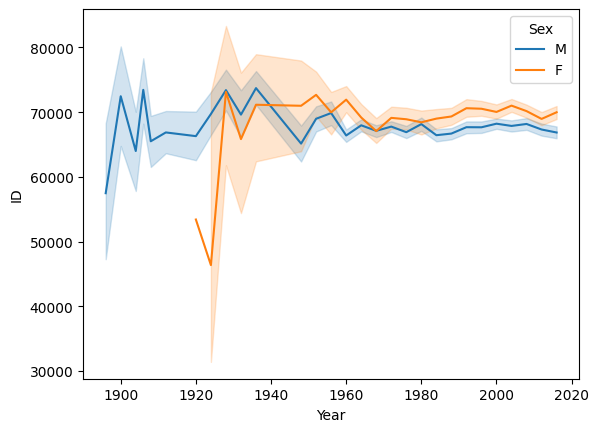

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Write your code belows
summer_df=df[df['Season']=='Summer']
gender_counts = (
    summer_df
      .groupby(['Year', 'Sex'])['ID']
      .nunique()
      .reset_index()
)
sns.lineplot(
    data=summer_df,
    x='Year',
    y='ID',
    hue='Sex'
)

## Distributions of Physical Attributes

<Axes: xlabel='Age', ylabel='Count'>

<Figure size 640x480 with 1 Axes>

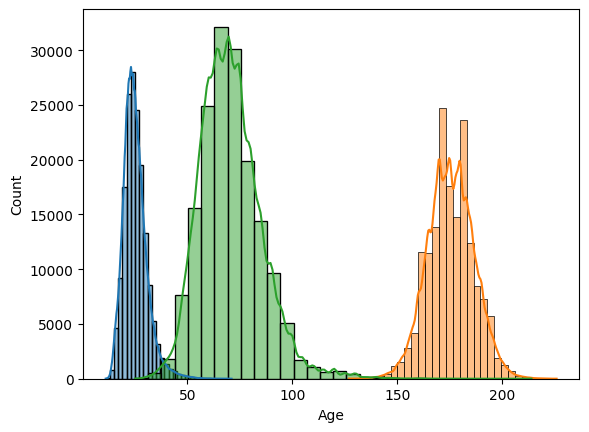

In [1]:
# Write your code below
sns.histplot(
    data=summer_df,
    x='Age',
    bins=30,
    kde=True
)
sns.histplot(
    data=summer_df,
    x='Height',
    bins=30,
    kde=True
)
sns.histplot(
    data=summer_df,
    x='Weight',
    bins=30,
    kde=True
)

## Comparing Physical Traits Across Sports

<Axes: xlabel='Sport', ylabel='Height'>

<Figure size 640x480 with 1 Axes>

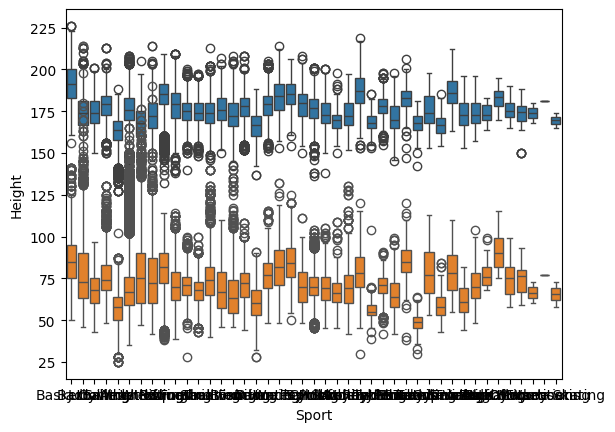

In [1]:
# Write your code below
target_sports = ['Basketball', 'Gymnastics', 'Weightlifting']
sports_df = df[df['Sport'].isin(target_sports)]
sns.boxplot(
    data=summer_df,
    x='Sport',
    y='Height',

)
sns.boxplot(
    data=summer_df,
    x='Sport',
    y='Weight',

)

## Tracing Athlete Evolution Over Time

<Figure size 1000x600 with 1 Axes>

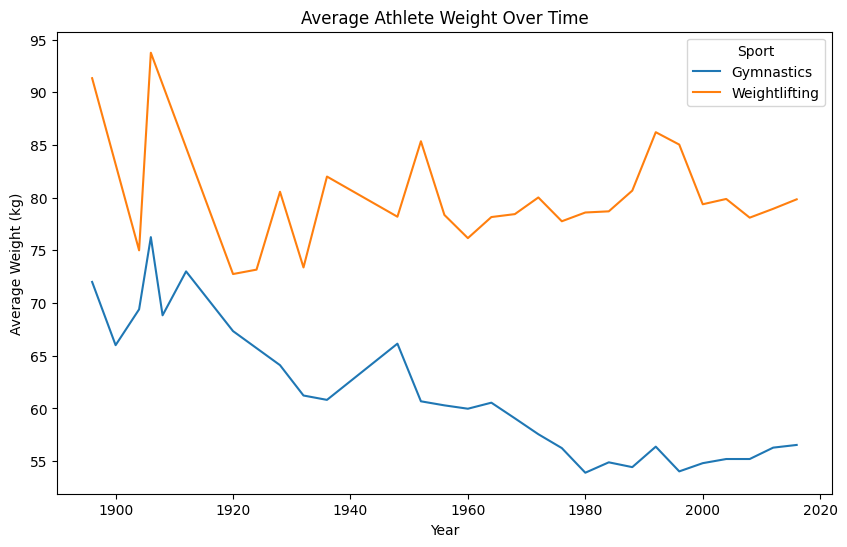

In [1]:
# Filter dataset
evo_df = df[df['Sport'].isin(['Gymnastics', 'Weightlifting'])]

# Aggregate mean weight per year and sport
weight_trends = evo_df.groupby(['Year', 'Sport'])['Weight'].mean().reset_index()

# Plot time-series data
plt.figure(figsize=(10, 6))
sns.lineplot(data=weight_trends, x='Year', y='Weight', hue='Sport')
plt.title("Average Athlete Weight Over Time")
plt.ylabel("Average Weight (kg)")
plt.show()

## Evaluating Medal Success by Country

<Figure size 1000x600 with 1 Axes>

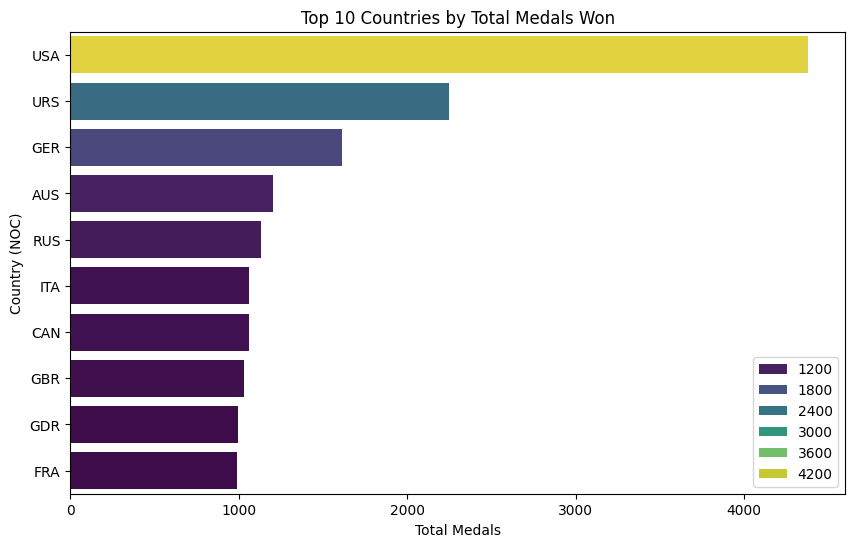

In [1]:
# Filter for actual medalists
medalists = df[df['Medal'] != 'None']

# Count medals per country and extract Top 10
top_countries = medalists.groupby('NOC')['Medal'].count().sort_values(ascending=False).head(10)

# Plot the ranking
plt.figure(figsize=(10, 6))
sns.barplot(hue=top_countries.values, x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top 10 Countries by Total Medals Won")
plt.xlabel("Total Medals")
plt.ylabel("Country (NOC)")
plt.show()